# Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers.


## 1. Introduction
This notebook explores the application of transfer learning using popular pre-trained convolutional neural network architectures to address the image classification task on the Oxford Flowers 102 dataset. Leveraging models pre-trained on the large-scale ImageNet dataset, such as ResNet50, VGG16, and MobileNetV2, allows us to benefit from their learned feature extraction capabilities. The goal is to adapt these powerful models to the finer-grained classification challenges presented by Oxford Flowers 102 , which consists of 102 distinct classes. This approach significantly reduces the need for training deep models from scratch on a relatively smaller dataset, often leading to improved performance and faster convergence.`

### Goal

The goal of this project, as stated in the markdown cells, is to apply transfer learning techniques using pre-trained convolutional neural networks (specifically ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. The objective is to leverage the feature extraction capabilities of these models, which were pre-trained on a large dataset like ImageNet, and adapt them for the finer-grained classification task of identifying 102 different categories of flowers. The project also aims to compare the performance of these different models on this dataset.

### Pre-trained Models

* ResNet50 (Residual Network 50): Known for its use of "residual connections" or "skip connections" which help train very deep networks by allowing gradients to flow through more easily. It has 50 layers.
* VGG16 (Visual Geometry Group 16): A relatively simple yet effective architecture characterized by its use of small 3x3 convolutional filters stacked in multiple layers. It has 16 layers.
* MobileNetV2 (Mobile Network version 2): Designed for mobile and embedded vision applications, it uses depthwise separable convolutions to reduce computation and memory requirements while maintaining accuracy.

### About dataset

The Oxford Flowers 102 dataset consists of 102 categories of flowers, with each category containing between 40 and 258 images. The images exhibit significant variations in scale, pose, and lighting. The dataset is split into training (1020 images), validation (1020 images), and testing (6149 images) sets.

## 2. Data Loading and Exploration
Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using tfds.load()

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)



print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.80UWKE_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.80UWKE_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

### Split
the dataset into training, validation, and testing sets (this dataset has these splits).

In [ ]:
train_set = dataset['train']
validation_set = dataset['validation']
test_set = dataset['test']

### Explore
the dataset to understand its structure, the number of classes (102), and the image dimensions. Display some sample images and their labels

Dataset Structure:
FeaturesDict({
    'file_name': Text(shape=(), dtype=string),
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=102),
})

Number of classes: 102
Image Shape: (None, None, 3)

Sample Images and Labels:


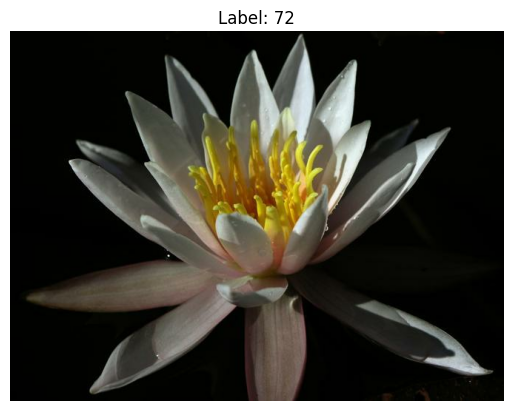

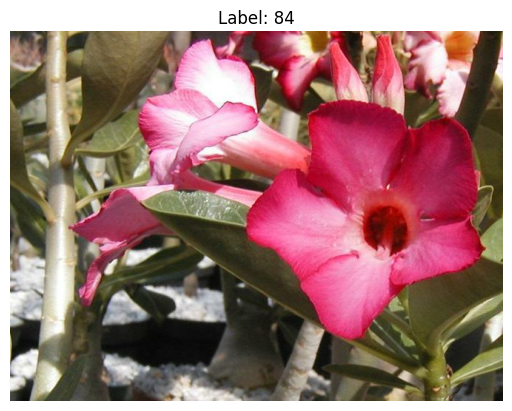

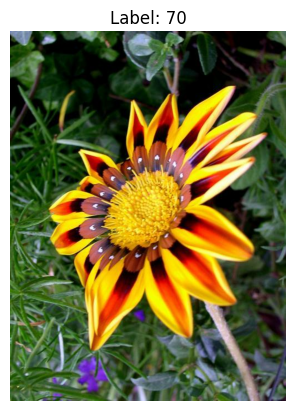

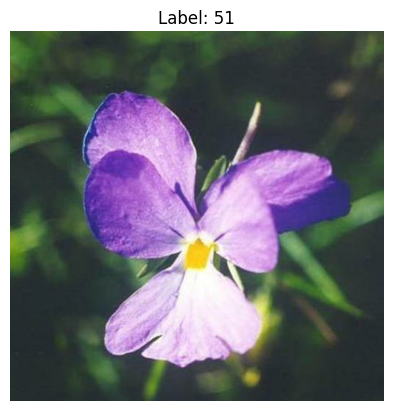

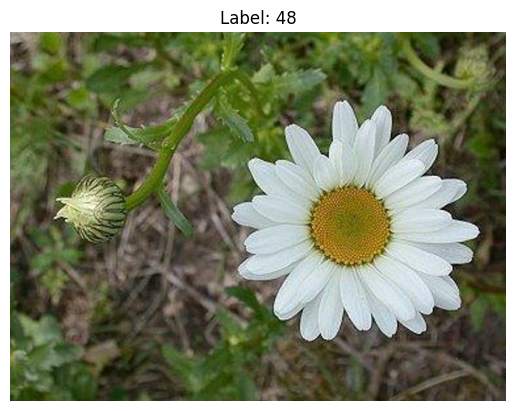

In [5]:
# Print information about the dataset
print("Dataset Structure:")
print(info.features)
print("\nNumber of classes:", info.features['label'].num_classes)
print("Image Shape:", info.features['image'].shape)

import matplotlib.pyplot as plt
# Display some sample images and labels
print("\nSample Images and Labels:")
for i, (image, label) in enumerate(train_set.take(5)):
    plt.figure()
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    if i == 4:
        break

plt.show()

## 3. Data Preprocessing:
Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.

In [ ]:
IMG_SIZE = 224

def preprocess_image_resnet50(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_resnet50(image)
    return image, label

def preprocess_image_vgg16(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_vgg16(image)
    return image, label

def preprocess_image_mobilenetv2(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_mobilenetv2(image)
    return image, label

# Apply preprocessing to each dataset
train_set_resnet50 = train_set.map(preprocess_image_resnet50).batch(32)
validation_set_resnet50 = validation_set.map(preprocess_image_resnet50).batch(32)
test_set_resnet50 = test_set.map(preprocess_image_resnet50).batch(32)

train_set_vgg16 = train_set.map(preprocess_image_vgg16).batch(32)
validation_set_vgg16 = validation_set.map(preprocess_image_vgg16).batch(32)
test_set_vgg16 = test_set.map(preprocess_image_vgg16).batch(32)

train_set_mobilenetv2 = train_set.map(preprocess_image_mobilenetv2).batch(32)
validation_set_mobilenetv2 = validation_set.map(preprocess_image_mobilenetv2).batch(32)
test_set_mobilenetv2 = test_set.map(preprocess_image_mobilenetv2).batch(32)

## 4. Model Adaptation and Training
Load and modify pre-trained models to fit the Oxford Flowers 102 classification task.

### 4.1 Using ResNet50

In [20]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) # Added Dropout layer
predictions = Dense(102, activation='softmax')(x)

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

model_resnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 4.2 Using VGG16

In [21]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout # Import Dropout

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x) # Added Dropout layer
predictions = Dense(102, activation='softmax')(x)
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 4.3 Using MobileNetV2

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout # Import Dropout

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Added Dropout layer
predictions = Dense(102, activation='softmax')(x)
model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

model_mobilenetv2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 4.4. Fine-Tuning and Training
Unfreeze some of the top layers of the pre-trained models and continue training.

In [23]:
epochs = 10

print(len(model_resnet50.layers))
print(len(model_vgg16.layers))
print(len(model_mobilenetv2.layers))


# Fine-tuning ResNet50
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False

for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

history_resnet50    = model_resnet50.fit(train_set_resnet50   , epochs=epochs, validation_data=validation_set_resnet50)



# Fine-tuning VGG16
for layer in model_vgg16.layers[:-5]:
    layer.trainable = False

for layer in model_vgg16.layers[-5:]:
    layer.trainable = True

history_vgg16       = model_vgg16.fit   (train_set_vgg16   , epochs=epochs, validation_data=validation_set_vgg16)



# Fine-tuning MobileNetV2
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False

for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

history_mobilenetv2 = model_mobilenetv2.fit(train_set_mobilenetv2, epochs=epochs, validation_data=validation_set_mobilenetv2)

179
23
158
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 641ms/step - accuracy: 0.1310 - loss: 4.5257 - val_accuracy: 0.1255 - val_loss: 18.3786
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.6840 - loss: 1.3872 - val_accuracy: 0.1686 - val_loss: 18.4067
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.8650 - loss: 0.5322 - val_accuracy: 0.1618 - val_loss: 21.7595
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.9428 - loss: 0.2092 - val_accuracy: 0.4098 - val_loss: 6.2108
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9583 - loss: 0.1344 - val_accuracy: 0.5931 - val_loss: 2.3626
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.9794 - loss: 0.1187 - val_accuracy: 0.5402 - val_loss: 4.2818
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.9773 - loss: 0.0821 - val_accuracy: 0.7029 - val_loss: 1.7096
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9842 - loss: 0.0988 -

## 5. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [24]:
acc_resnet50    = model_resnet50.evaluate(test_set_resnet50)[1]
acc_vgg16       = model_vgg16.evaluate(test_set_vgg16)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(test_set_mobilenetv2)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')

193/193 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.7111 - loss: 1.4868
193/193 ━━━━━━━━━━━━━━━━━━━━ 32s 164ms/step - accuracy: 0.6982 - loss: 1.2538
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.2546 - loss: 6.5690
ResNet50 Accuracy: 0.71
VGG16 Accuracy: 0.70
MobileNetV2 Accuracy: 0.26


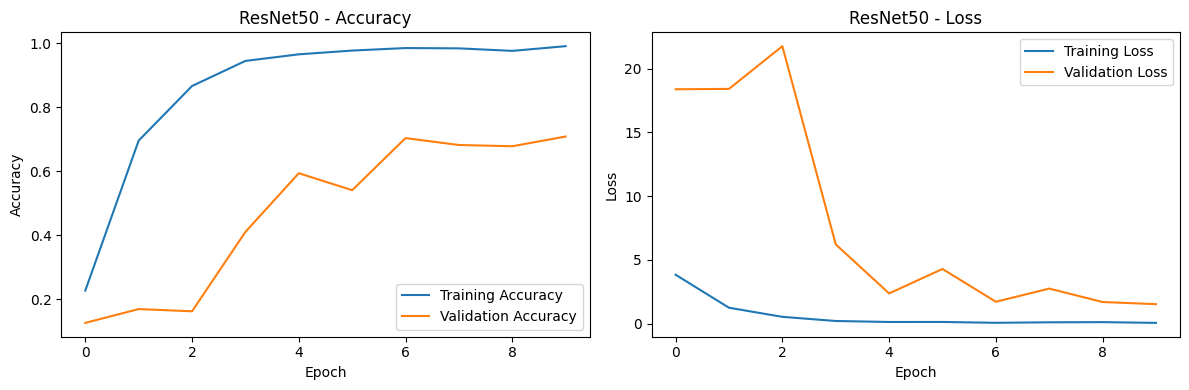

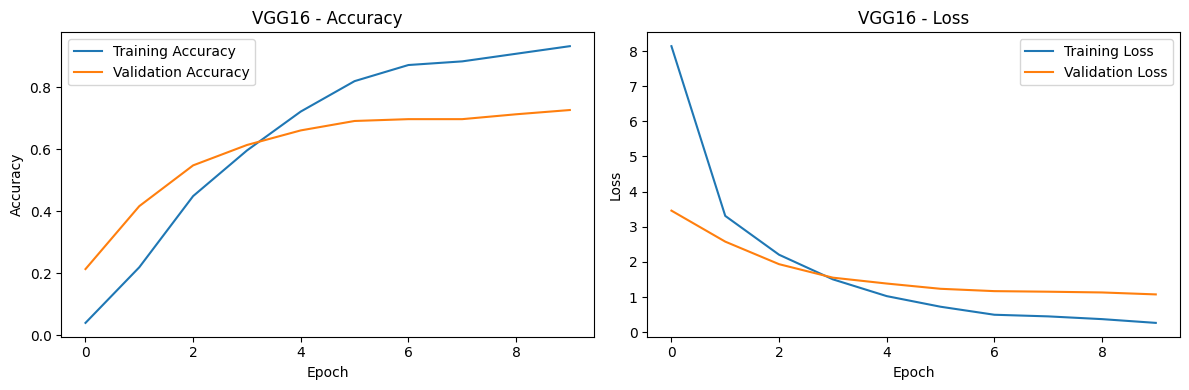

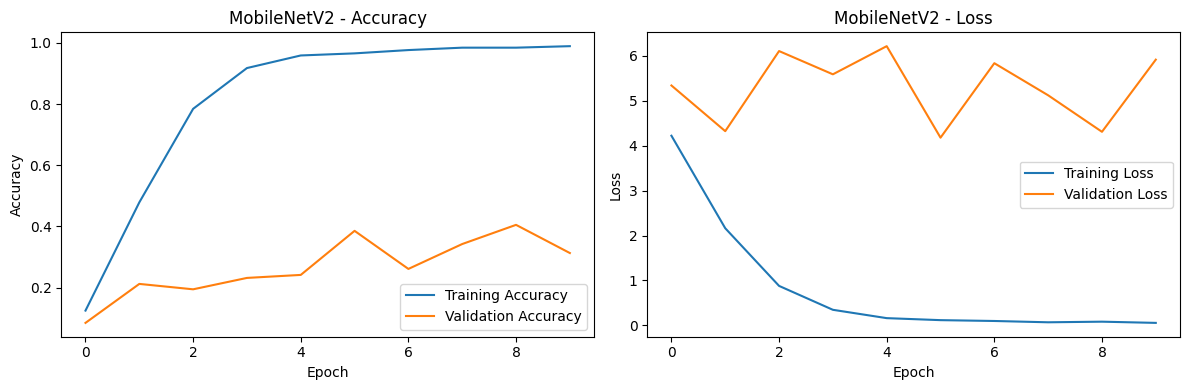

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

* ResNet50: The training accuracy quickly goes to 1.0, and the training loss drops very low. The validation accuracy increases steadily, while the validation loss decreases, but there is a gap between training and validation metrics. This suggests the model is learning well on the training data and generalizing to the validation data, but there might be some slight overfitting as the training accuracy is perfect.

* VGG16: The training accuracy increases and training loss decreases, but not as rapidly as ResNet50. The validation accuracy also increases and validation loss decreases, following the training curves more closely than ResNet50, which might indicate less overfitting compared to ResNet50, but overall lower performance.

* MobileNetV2: The training accuracy goes to 1.0 and training loss drops very low, similar to ResNet50. However, the validation accuracy stays quite low and validation loss remains high. This pattern strongly suggests that the MobileNetV2 model is severely overfitting to the training data and is not generalizing well to the validation set at all.

* In summary, the graphs show different training behaviors for each model. ResNet50 shows good learning and generalization with some potential for slight overfitting. VGG16 shows more moderate learning and better alignment between training and validation curves. MobileNetV2 is clearly overfitting and not performing well on the validation data.

Based on these graphs, ResNet50 appears to be the most promising model, although further steps to mitigate overfitting could be explored for all models.

## Project Summary

*   **Data Loading and Preprocessing**: Loaded the Oxford_Flowers_102 dataset and preprocessed images using model-specific functions (ResNet50, VGG16, MobileNetV2).
*   **Model Adaptation**: Loaded pre-trained ResNet50, VGG16, and MobileNetV2 models (without top layers), added new classification layers for 102 classes, and initially froze base model layers.
*   **Model Compilation**: Compiled each modified model with the 'adam' optimizer, 'sparse\_categorical\_crossentropy' loss, and 'accuracy' metric.
*   **Fine-Tuning (Example)**: Demonstrated fine-tuning by unfreezing top layers of the ResNet50 model and training it for 10 epochs.
*   **Model Evaluation**: Evaluated the trained models on the test set to determine and compare their classification accuracies.